¡Hola, Manuel!

Mi nombre es Tonatiuh Cruz. Me complace revisar tu proyecto hoy.

Al identificar cualquier error inicialmente, simplemente los destacaré. Te animo a localizar y abordar los problemas de forma independiente como parte de tu preparación para un rol como data-scientist. En un entorno profesional, tu líder de equipo seguiría un enfoque similar. Si encuentras la tarea desafiante, proporcionaré una pista más específica en la próxima iteración.

Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o elimines**.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Éxito. Todo está hecho correctamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con comentarios en rojo.
</div>

Puedes responderme utilizando esto:

<div class="alert alert-block alert-info">

# 1. Importación de librerías necesarias

In [78]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, f1_score, roc_auc_score
from sklearn.utils import resample

# librerías de visualización
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# 2. Cargado y preparado del dataset

In [79]:
df = pd.read_csv('/datasets/Churn.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


In [80]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [81]:
# eliminación de datos que no aportan en la predicción
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           9091 non-null   float64
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 859.5+ KB


In [82]:
# comprobación de valores duplicados
df.duplicated().sum() 

0

In [83]:
# comprobación de valores nulos
df.isnull().sum()

CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure             909
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64

In [84]:
df['Tenure'].describe()

count    9091.000000
mean        4.997690
std         2.894723
min         0.000000
25%         2.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: Tenure, dtype: float64

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Excelente trabajo con la carga de la información y su exploración inicial.  

Además, lo complementas con un análisis de los registros duplicados que como aprendiste en cursos pasados sirve para asegurar que nuestros resultados no estarán sesgados

In [85]:
# Se comprueba que la media y mediana son similares

# se completan los valores ausentes con la media
df['Tenure'].fillna(df['Tenure'].mean(), inplace=True)

# conversión de columna Tenure a números enteros
df['Tenure'] = df['Tenure'].astype(int)

In [86]:
# Codificación de variables categóricas
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [87]:
df.head(10)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
5,645,44,8,113755.78,2,1,0,149756.71,1,0,1,1
6,822,50,7,0.00,2,1,1,10062.80,0,0,0,1
7,376,29,4,115046.74,4,1,0,119346.88,1,1,0,0
8,501,44,4,142051.07,2,0,1,74940.50,0,0,0,1
9,684,27,2,134603.88,1,1,1,71725.73,0,0,0,1


In [88]:

# Distribución de la variable objetivo 
df['Exited'].value_counts(normalize=True)


0    0.7963
1    0.2037
Name: Exited, dtype: float64

# 3. Entrenamiento del modelo sin correción de desequilibrio

## Segmentación de los datos

In [89]:
# características
features = df.drop(columns='Exited') 

# objetivo
target = df['Exited']

In [90]:
# División del conjunto de datos
# entrenamiento, validación y prueba

features_temp, features_valid, target_temp, target_valid = train_test_split(features, target, test_size=0.2, random_state=12345)
features_train, features_test, target_train, target_test = train_test_split(features_temp, target_temp, test_size=0.25, random_state=12345)

print(f'Porcentaje entrenamiento: {round(len(target_train) * 100 / len(target))}%')
print(f'Porcentaje validación: {round(len(target_valid) * 100 / len(target))}%')
print(f'Porcentaje prueba: {round(len(target_test) * 100 / len(target))}%')

Porcentaje entrenamiento: 60%
Porcentaje validación: 20%
Porcentaje prueba: 20%


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Muy buen trabajo dividiendo los datos en los conjuntos de entrenamiento, prueba y validación.
</div>

### Bosque aleatorio

In [91]:
# definición y entrenamiento del modelo
model_forest = RandomForestClassifier(max_depth=10, random_state=12345)
model_forest.fit(features_train, target_train)

# predicción
target_predict = model_forest.predict(features_valid)

# obtención valores F1 y ROC-AUC
f1_model_forest = f1_score(target_valid, target_predict)
probabilities_valid = model_forest.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
roc_auc_model_forest = roc_auc_score(target_valid, probabilities_one_valid)

print(f'Valor F1 (sin corrección): {f1_model_forest:.3f}')
print(f'ROC-AUC (sin corrección): {roc_auc_model_forest:.3f}')

Valor F1 (sin corrección): 0.558
ROC-AUC (sin corrección): 0.870


### Regresión logística

In [92]:
# definición y entrenamiento del modelo
model_regression = LogisticRegression(random_state=12345)
model_regression.fit(features_train, target_train)

# predicción
target_predict = model_regression.predict(features_valid)

# obtención valores F1 y ROC-AUC
f1_model_regression = f1_score(target_valid, target_predict)
probabilities_valid = model_regression.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
roc_auc_model_regression = roc_auc_score(target_valid, probabilities_one_valid)

print(f'Valor F1 (sin corrección): {f1_model_regression:.3f}')
print(f'ROC-AUC (sin corrección): {roc_auc_model_regression:.3f}')

Valor F1 (sin corrección): 0.103
ROC-AUC (sin corrección): 0.671


# 4. Mejora de la calidad del modelo

### Bosque aleatorio sobremuestreo

In [93]:
# reconstrucción del dataset de entrenamiento
df_train = pd.concat([features_train, target_train.rename('target')], axis=1)

# separación clase mayoritaria y minoritaria
major = df_train[df_train['target'] == 0]  # Ejemplares de la clase 0 (mayoría)
minor = df_train[df_train['target'] == 1]  # Ejemplares de la clase 1 (minoría)

# sobremuestreo de la clase minoritaria
test_samples = int(len(major)/2) # se evaluaron diferentes valores como que fueran iguales, 
                                 # multiplicado por 2 y el mejor resultado fue dividido entre 2

#minor_upsampled = resample(minor, replace=True, n_samples=len(major), random_state=12345)
minor_upsampled = resample(minor, replace=True, n_samples=test_samples, random_state=12345)

# concatenación de las clases original y sobremuestreada
train_up = pd.concat([major, minor_upsampled])

# separación de características y objetivo
features_train_up = train_up.drop(columns=['target'])
target_train_up = train_up['target']

# definición y entrenamiento del modelo
model_forest_up = RandomForestClassifier(max_depth=10, random_state=12345)
model_forest_up.fit(features_train_up, target_train_up)

# predicción
target_pred_up = model_forest_up.predict(features_valid)

# obtención valores F1 y ROC-AUC
f1_up = f1_score(target_valid, target_pred_up)
probabilities_valid = model_forest_up.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
roc_auc_model_up = roc_auc_score(target_valid, probabilities_one_valid)

print(f'Valor F1 bosque aleatorio con sobremuestreo: {f1_up:.3f}')
print(f'ROC-AUC bosque aleatorio con sobremuestreo: {roc_auc_model_up:.3f}')

Valor F1 bosque aleatorio con sobremuestreo: 0.607
ROC-AUC bosque aleatorio con sobremuestreo: 0.863


In [94]:
# Distribución de la variable objetivo 
target_train_up.value_counts(normalize=True)

0    0.666713
1    0.333287
Name: target, dtype: float64

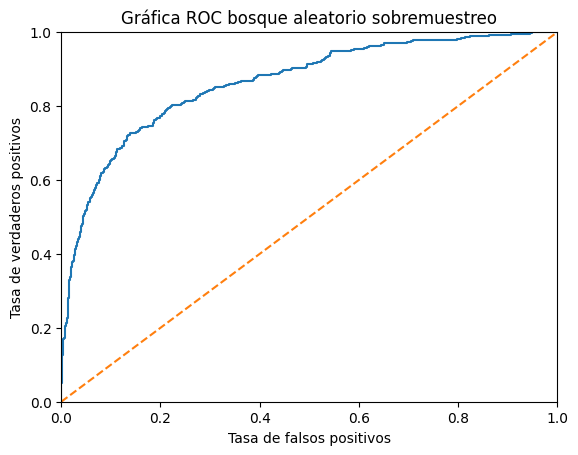

In [95]:
fpr, tpr, thresholds = roc_curve(target_valid, probabilities_one_valid)

plt.figure()

# < traza la gráfica >
plt.plot(fpr, tpr)

# Curva ROC para modelo aleatorio (parece una línea recta)
plt.plot([0, 1], [0, 1], linestyle='--')

# < utiliza las funciones plt.xlim() y plt.ylim() para
#   establecer el límite para los ejes de 0 a 1 >
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

# < utiliza las funciones plt.xlabel() y plt.ylabel() para
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")

# < agrega el encabezado 
plt.title("Gráfica ROC bosque aleatorio sobremuestreo")

plt.show()

### Bosque aleatorio submuestreo

In [96]:
# reconstrucción del dataset de entrenamiento
df_train = pd.concat([features_train, target_train.rename('target')], axis=1)

# separación clase mayoritaria y minoritaria
major = df_train[df_train['target'] == 0]  # Ejemplares de la clase 0 (mayoría)
minor = df_train[df_train['target'] == 1]  # Ejemplares de la clase 1 (minoría)

# submuestreo de la clase mayoritaria
test_samples = int(len(minor)) # se evaluaron diferentes valores como que fueran iguales, 
                                 # multiplicado por 2 y el mejor resultado fue dividido entre 2
major_down = resample(major, replace=True, n_samples=test_samples, random_state=12345)

# concatenación de las clases original y sobremuestreada
train_down = pd.concat([major_down, minor])

# separación de características y objetivo
features_train_down = train_down.drop(columns=['target'])
target_train_down = train_down['target']

# definición y entrenamiento del modelo
model_forest_down = RandomForestClassifier(max_depth=10, random_state=12345)
model_forest_down.fit(features_train_down, target_train_down)

# predicción
target_pred_down = model_forest_down.predict(features_valid)

# obtención valores F1 y ROC-AUC
f1_down = f1_score(target_valid, target_pred_down)
probabilities_valid = model_forest_down.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
roc_auc_model_down = roc_auc_score(target_valid, probabilities_one_valid)

print(f'Valor F1 bosque aleatorio con submuestreo: {f1_down:.3f}')
print(f'ROC-AUC bosque aleatorio con submuestreo: {roc_auc_model_down:.3f}')

Valor F1 bosque aleatorio con submuestreo: 0.603
ROC-AUC bosque aleatorio con submuestreo: 0.863


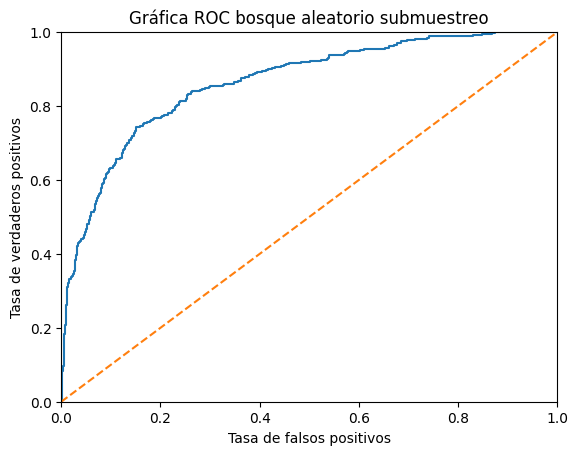

In [97]:
fpr, tpr, thresholds = roc_curve(target_valid, probabilities_one_valid)

plt.figure()

# < traza la gráfica >
plt.plot(fpr, tpr)

# Curva ROC para modelo aleatorio (parece una línea recta)
plt.plot([0, 1], [0, 1], linestyle='--')

# < utiliza las funciones plt.xlim() y plt.ylim() para
#   establecer el límite para los ejes de 0 a 1 >
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

# < utiliza las funciones plt.xlabel() y plt.ylabel() para
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")

# < agrega el encabezado 
plt.title("Gráfica ROC bosque aleatorio submuestreo")

plt.show()

In [98]:
# Distribución de la variable objetivo 
target_train_down.value_counts(normalize=True)

0    0.5
1    0.5
Name: target, dtype: float64

### Regresión logística balanceada

In [99]:
# definición y entrenamiento del modelo
model_bal = LogisticRegression(class_weight='balanced', solver='liblinear', random_state=12345)
model_bal.fit(features_train, target_train)

# predicción
target_pred = model_bal.predict(features_valid)

# obtención valores F1 y ROC-AUC
f1_model_bal = f1_score(target_valid, target_pred)
probabilities_valid = model_bal.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
roc_auc_model_bal = roc_auc_score(target_valid, probabilities_one_valid)

print(f'Valor F1 regresión logística con clase balanceada: {f1_model_bal:.3f}')
print(f'ROC-AUC regresión logística con clase balanceada: {roc_auc_model_bal:.3f}')

Valor F1 regresión logística con clase balanceada: 0.445
ROC-AUC regresión logística con clase balanceada: 0.717


### Regresión logística sobremuestreo

In [100]:
# reconstrucción del dataset de entrenamiento
df_train = pd.concat([features_train, target_train.rename('target')], axis=1)

# separación clase mayoritaria y minoritaria
major = df_train[df_train['target'] == 0]  # Ejemplares de la clase 0 (mayoría)
minor = df_train[df_train['target'] == 1]  # Ejemplares de la clase 1 (minoría)

# sobremuestreo de la clase minoritaria
minor_upsampled = resample(minor, replace=True, n_samples=len(major), random_state=12345)

# concatenación de las clases original y sobremuestreada
train_up = pd.concat([major, minor_upsampled])

# separación de características y objetivo
features_train_up = train_up.drop(columns=['target'])
target_train_up = train_up['target']

# definición y entrenamiento del modelo
model_up = LogisticRegression(solver='liblinear', random_state=12345)
model_up.fit(features_train_up, target_train_up)

# predicción
target_pred_up = model_up.predict(features_valid)

# obtención valores F1 y ROC-AUC
f1_up = f1_score(target_valid, target_pred_up)
probabilities_valid = model_up.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
roc_auc_model_up = roc_auc_score(target_valid, probabilities_one_valid)

# 8. Imprimir la métrica F1 resultante
print(f'Valor F1 regresión logística con sobremuestreo: {f1_up:.3f}')
print(f'ROC-AUC regresión logística con sobremuestreo: {roc_auc_model_up:.3f}')

Valor F1 regresión logística con sobremuestreo: 0.452
ROC-AUC regresión logística con sobremuestreo: 0.716


### Regresión logística submuestreo

In [101]:
# reconstrucción del dataset de entrenamiento
df_train = pd.concat([features_train, target_train.rename('target')], axis=1)

# submuestreo de la clase mayoritaria
major_down = resample(major, replace=False, n_samples=len(minor), random_state=12345) 

# concatenación de las clases original y sobremuestreada
train_down = pd.concat([major_down, minor])

# separación de características y objetivo
features_train_down = train_down.drop(columns=['target'])
target_train_down = train_down['target']

# definición y entrenamiento del modelo
model_down = LogisticRegression(solver='liblinear', random_state=12345)
model_down.fit(features_train_down, target_train_down)

# predicción
target_pred_down = model_down.predict(features_valid)

# obtención valores F1 y ROC-AUC
f1_down = f1_score(target_valid, target_pred_down)
probabilities_valid = model_down.predict_proba(features_valid)
probabilities_one_valid = probabilities_valid[:, 1]
roc_auc_model_down = roc_auc_score(target_valid, probabilities_one_valid)

print(f'Valor F1 regresión logística con submuestreo: {f1_down:.3f}')
print(f'ROC-AUC regresión logística con submuestreo: {roc_auc_model_down:.3f}')

Valor F1 regresión logística con submuestreo: 0.449
ROC-AUC regresión logística con submuestreo: 0.719


# 5. Prueba final

In [102]:
# se selecciona el modelo de bosque aleatorio con sobremuestreo ya que dio mejores resultados

final_forest_prediction = model_forest_up.predict(features_test)

f1_final = f1_score(target_test, final_forest_prediction)
probabilities_test_final = model_forest_up.predict_proba(features_test)
probabilities_one_test_final = probabilities_test_final[:, 1]
roc_auc_model_final = roc_auc_score(target_test, probabilities_one_test_final)

print(f'Valor F1 bosque aleatorio final con sobremuestreo: {f1_final:.3f}')
print(f'ROC-AUC rbosque aleatorio final con sobremuestreo: {roc_auc_model_down:.3f}')

Valor F1 bosque aleatorio final con sobremuestreo: 0.602
ROC-AUC rbosque aleatorio final con sobremuestreo: 0.719


<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Entrenaste correctamente los modelos teniendo en cuenta el desequilibrio de clases. Ademeás usas diferentes sets de hiperparámetros para elegir los que mejor se ajustaran a los datos.

Ya solamente te recomiendo complementarlo con la gráfica ROC para evaluar el rendimiento del modelo. Este tipo de visualización permite comparar de forma efectiva distintos clasificadores y elegir el más adecuado.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Gran trabajo con el ajuste!

### Gráfica ROC

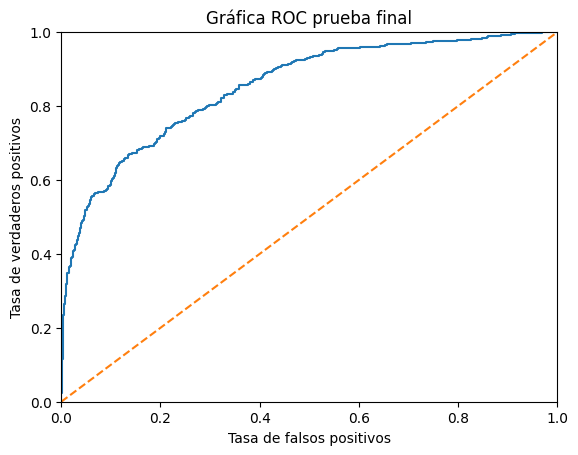

In [103]:
fpr, tpr, thresholds = roc_curve(target_test, probabilities_one_test_final)

plt.figure()

# < traza la gráfica >
plt.plot(fpr, tpr)

# Curva ROC para modelo aleatorio (parece una línea recta)
plt.plot([0, 1], [0, 1], linestyle='--')

# < utiliza las funciones plt.xlim() y plt.ylim() para
#   establecer el límite para los ejes de 0 a 1 >
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

# < utiliza las funciones plt.xlabel() y plt.ylabel() para
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")

# < agrega el encabezado 
plt.title("Gráfica ROC prueba final")

plt.show()

### Conclusión

Se evaluaron diferentes parámetros en los modelos de regresión de bosque aleatorio con submuestreo y sobremuestreo, buscando cumplir el mínimo de valor de F1 superior a 0.59. Con las variables de entrenamiento se lograba este valor, pero al realizar la prueba final no, por lo que se comenzó a modificar las longitudes de las muestras en menor y mayor proporción, respectivamente. Luego de identificar unas configuraciones adecuadas, se logró un valor de F1 de 0.6 (moderadamente aceptable) y ROC-AUC de 0.86 (aceptable), cumpliendo con un modelo predictivo para identificar la posible salida de los clientes antiguos del banco Beta Bank.